<a href="https://colab.research.google.com/github/ankit1141r/minescraft_assignments/blob/main/titanicdataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1....**LOAD DATASET FROM KAGGLE **

url=https://www.kaggle.com/datasets/yasserh/titanic-dataset

download it as a csv file from kaggle

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

importing usefull libraries

In [5]:
df=pd.read_csv("Titanic-Dataset.csv")

read csv file using pandas

In [6]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


preview  data

2..... Clean data (handle missing values like Age).


In [7]:
#check missing values
missing_values=df.isnull().sum()
print(missing_values)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [8]:
# full age null values with mean of the ages............
df['Age'].fillna(df['Age'].mean(), inplace=True)
#check again
missing_values=df.isnull().sum()
print(missing_values)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


/tmp/ipykernel_8726/3146105263.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [9]:
# remove cabin column because out of 891 rows 687 are none
df.drop(columns=['Cabin'], inplace=True)
#check again
missing_values=df.isnull().sum()
print(missing_values)

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64


In [10]:
#mode
mode_value = df['Embarked'].mode()[0]

In [11]:
# full age null values with mode of the embarked.........
df['Embarked'].fillna(mode_value, inplace=True)
#check again
missing_values=df.isnull().sum()
print(missing_values)

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_8726/2333637972.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(mode_value, inplace=True)


**3..........     Answer questions such as:**

* Who survived more: males or females?

In [21]:
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100
print(survival_by_sex)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


here it is clear that , 74% females are survived and only approx 19 % males are survived.

* Did passenger class affect survival chances?

In [23]:
survival_by_class = df.groupby('Pclass')['Survived'].mean() * 100
print(survival_by_class)

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


from it , it is clear that , passenger class affects survival chances,beacuse from 1st class seats 63% passengers survived . from 2nd class seats 47% passengers survived and from 3rd class seats only 24% passengers survived.

In [27]:
bins = [0, 12, 18, 30, 50, 80]
labels = ['Child (0-12)', 'Teen (13-18)', 'Young Adult (19-30)', 'Adult (31-50)', 'Senior (51+)']


df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right =True)

survival_rate = df.groupby('AgeGroup')['Survived'].mean() * 100
print(survival_rate)

AgeGroup
Child (0-12)           57.971014
Teen (13-18)           42.857143
Young Adult (19-30)    33.109620
Adult (31-50)          42.323651
Senior (51+)           34.375000
Name: Survived, dtype: float64


/tmp/ipykernel_8726/102978361.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate = df.groupby('AgeGroup')['Survived'].mean() * 100


here is the age group survial -----------

Child (0-12)     --      58%

Teen (13-18)     --      43%

Young Adult (19-30) --   33%

Adult (31-50)   --       42%

Senior (51+)    --       34%

**4....... Visualize using Seaborn / Matplotlib:**

* Bar chart of survival by gender.

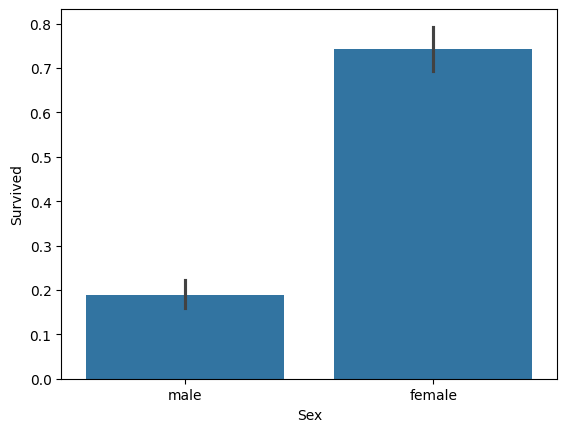

In [28]:
sns.barplot(x="Sex",y="Survived",data=df)
plt.show()

* Bar chart of survival by class.

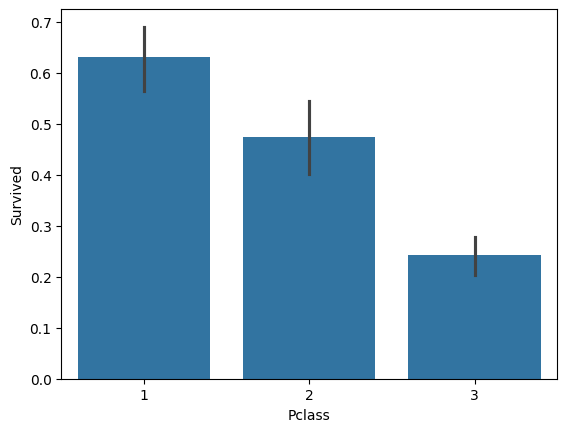

In [29]:
sns.barplot(x="Pclass",y="Survived",data=df)
plt.show()

* Histogram of passenger ages.

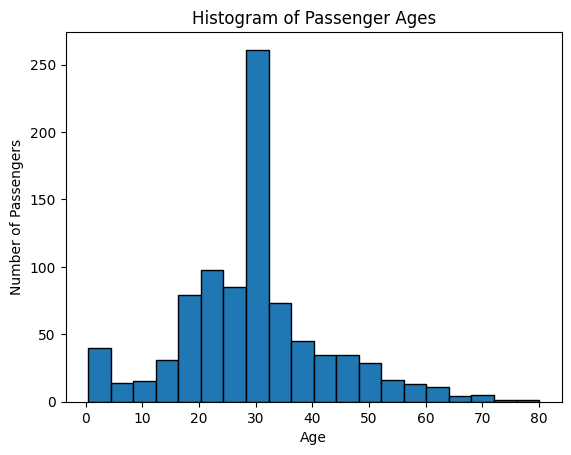

In [34]:
plt.hist(df['Age'].dropna(), bins=20, edgecolor='black')
plt.title("Histogram of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()